## [About Dataset](https://www.kaggle.com/datasets/shashanks1202/apartment-rent-data).

#### <span style="color: yellow;">1. Informacja ze strony 'kaggle'.</span>

This dataset comprises detailed information on apartment rentals, ideal for various machine learning tasks including clustering, classification, and regression. It features a comprehensive set of attributes that capture essential aspects of rental listings, such as:

- Identifiers & Location: Includes unique identifiers (id), geographic details (address, cityname, state, latitude, longitude), and the source of the classified listing.
- Property Details: Provides information on the apartment's category, title, body, amenities, number of bathrooms, bedrooms, and square_feet (size of the apartment).
- Pricing Information: Contains multiple features related to pricing, including price (rental price), price_display (displayed price), price_type (price in USD), and fee.
- Additional Features: 

    - Indicates whether the apartment has a photo (has_photo), 
    - whether pets are allowed (pets_allowed), 
    - currency
    - time of listing creation.

The dataset is well-cleaned, ensuring that critical columns like price and square_feet are never empty. This makes it a robust resource for developing predictive models and performing in-depth analyses on rental trends and property characteristics.

#### <span style="color: yellow;">2. Komentarz zespołu.</span>

- Nie wszystkie dane są pełne, można zrobić "doczyszczenie" poprzez zmianę null w kolumnie pets_allowed na wartość 'None'
- W linii 8809 z identyfikatorem 5508674935 widzę zapis 

    <span style="color: orange;">Kensington Village Apartments was reborn with 100% "New Everything.;"</span>
    
  który zaburza wczytanie pliku. Trzeba w ramach czyszczenia tej linii wyciągnąć średnik za cudzysłów. 

    <span style="color: green;">Kensington Village Apartments was reborn with 100% "New Everything.";</span>

- Podobnie dla linii z identyfikatorami 5508674416, 5197977383
- Jedna linia (id:5667488036) nie ma ceny, może ją po prostu wyciąć?
- Jedna linia ma w kolumnie zapis "Monthly|Weekly", ma wprawdzie cenę, ale to dziwnie wygląda. Może ją też pominąć?
- ilość adresów = null nam nie przeszkadza, dopóki mamy miasto i stan
- 11 zapisów szerokości i długści geograficznej nie ma miasta i stanu. Te dane możemy znaleźć ręcznie przy pomocy google maps



 

In [9]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as ss
import matplotlib.pyplot as plt
import missingno as msno

# %matplotlib inline włącza wyświetlanie wykresów bezpośrednio w notebooku (np. Jupyter)
# %config InlineBackend.figure_format = 'retina' ustawia wysoką rozdzielczość wykresów (tzw. retina), 
# dzięki czemu wyglądają ostrzej na ekranach o dużej gęstości pikseli. 
%matplotlib inline 
%config InlineBackend.figure_format = 'retina'

# df = pd.read_csv("apartments_for_rent_classified_10K.csv", sep=';', encoding="cp1250")
df = pd.read_csv("apartments_for_rent_classified_100K.csv", sep=';', encoding="cp1250")
# df = pd.read_csv("apartments_for_rent_classified_8809.csv", sep=';', encoding="cp1250")
# df.head(5)

C:\Users\Grażyna\AppData\Local\Temp\ipykernel_1752\124863073.py:15: DtypeWarning: Columns (0: address) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("apartments_for_rent_classified_100K.csv", sep=';', encoding="cp1250")


In [6]:
# sprawdzenie czystości danych
df.isna().sum()   

id                   0
category             0
title                0
body                 0
amenities        16085
bathrooms           63
bedrooms           124
currency             0
fee                  0
has_photo            0
pets_allowed     60686
price                1
price_display        1
price_type           0
square_feet          0
address          91967
cityname           302
state              302
latitude            25
longitude           25
source               0
time                 0
dtype: int64

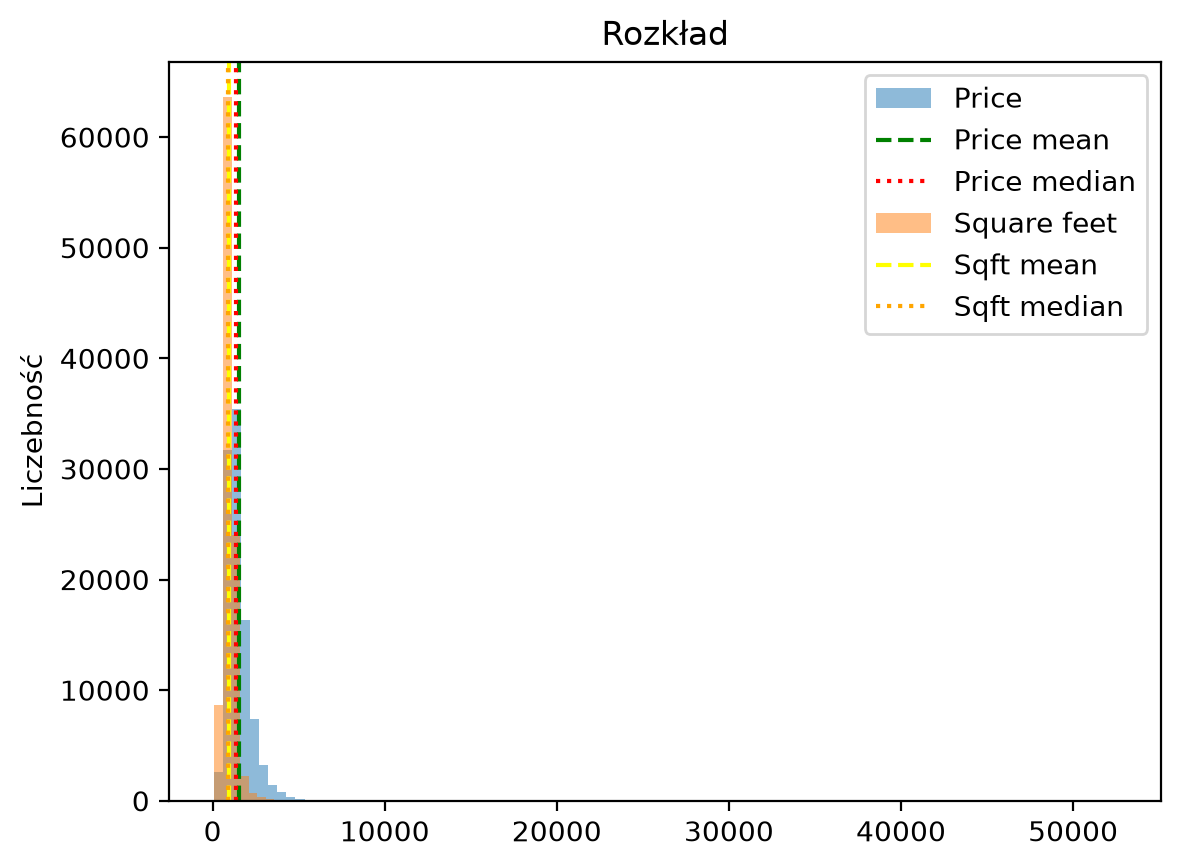

In [ ]:
# Poziom alfa zmienia przezroczystość twojego wykresu.

# wyżej jest import matplotlib.pyplot as plt

plt.hist(df['price'], bins=100, alpha=.5, label='Price')
plt.axvline(df['price'].mean(), linestyle="dashed", color="green", label='Price mean')
plt.axvline(df['price'].median(), linestyle="dotted", color="red", label='Price median')

plt.hist(df['square_feet'], bins=100, alpha=.5, label='Square feet')
plt.axvline(df['square_feet'].mean(), linestyle="dashed", color="yellow", label='Sqft mean')
plt.axvline(df['square_feet'].median(), linestyle="dotted", color="orange", label='Sqft median')

plt.title("Rozkład")
plt.ylabel("Liczebność")
plt.legend()
plt.show()




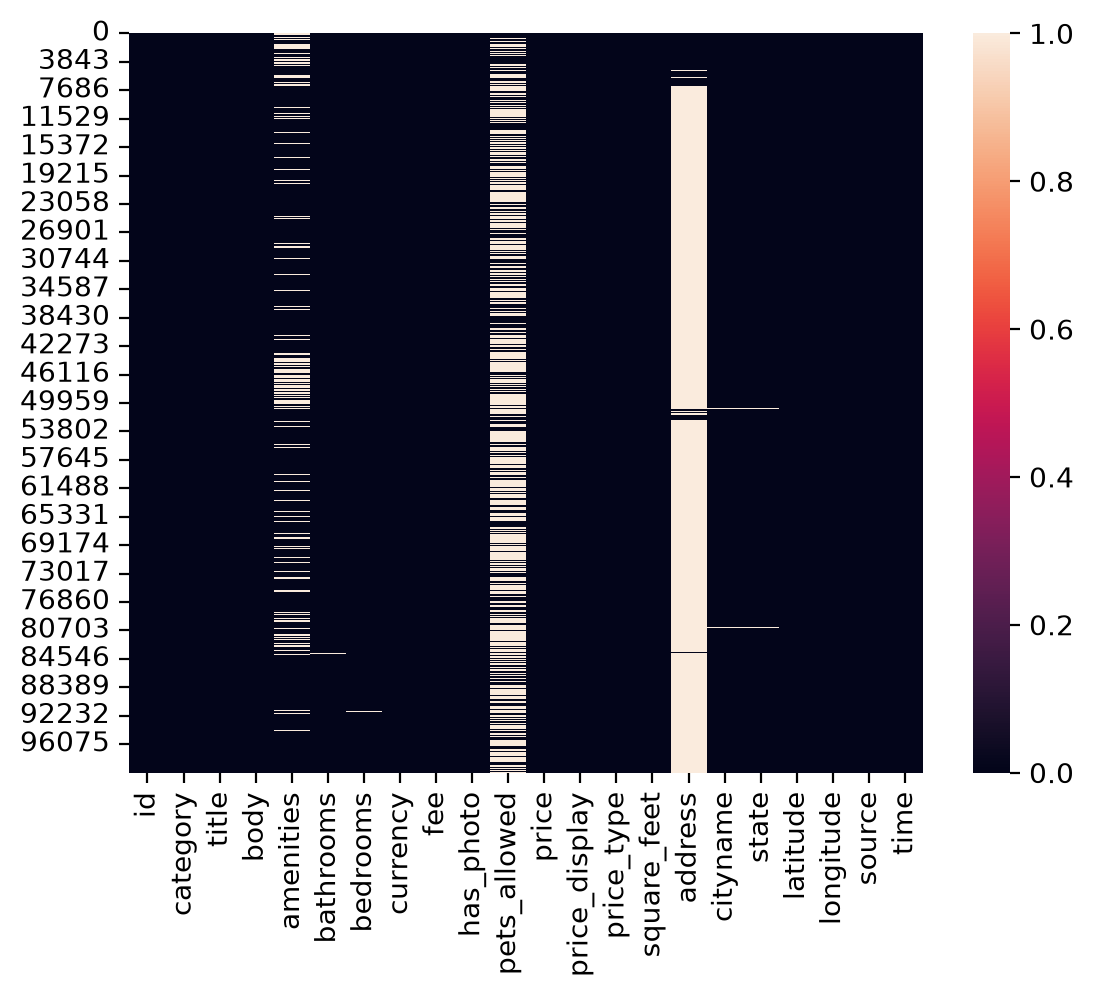

In [8]:
import seaborn as sns
sns.heatmap(df.isna());

Najważniejsza rzecz: heatmap z missingno (msno.heatmap(df)) nie pokazuje korelacji między zmiennymi, tylko korelacje braków danych. To jest częsty błąd interpretacyjny, więc zacznijmy od jasnej odpowiedzi. Jak często braki danych w jednej kolumnie współwystępują z brakami w innej.

<Axes: >

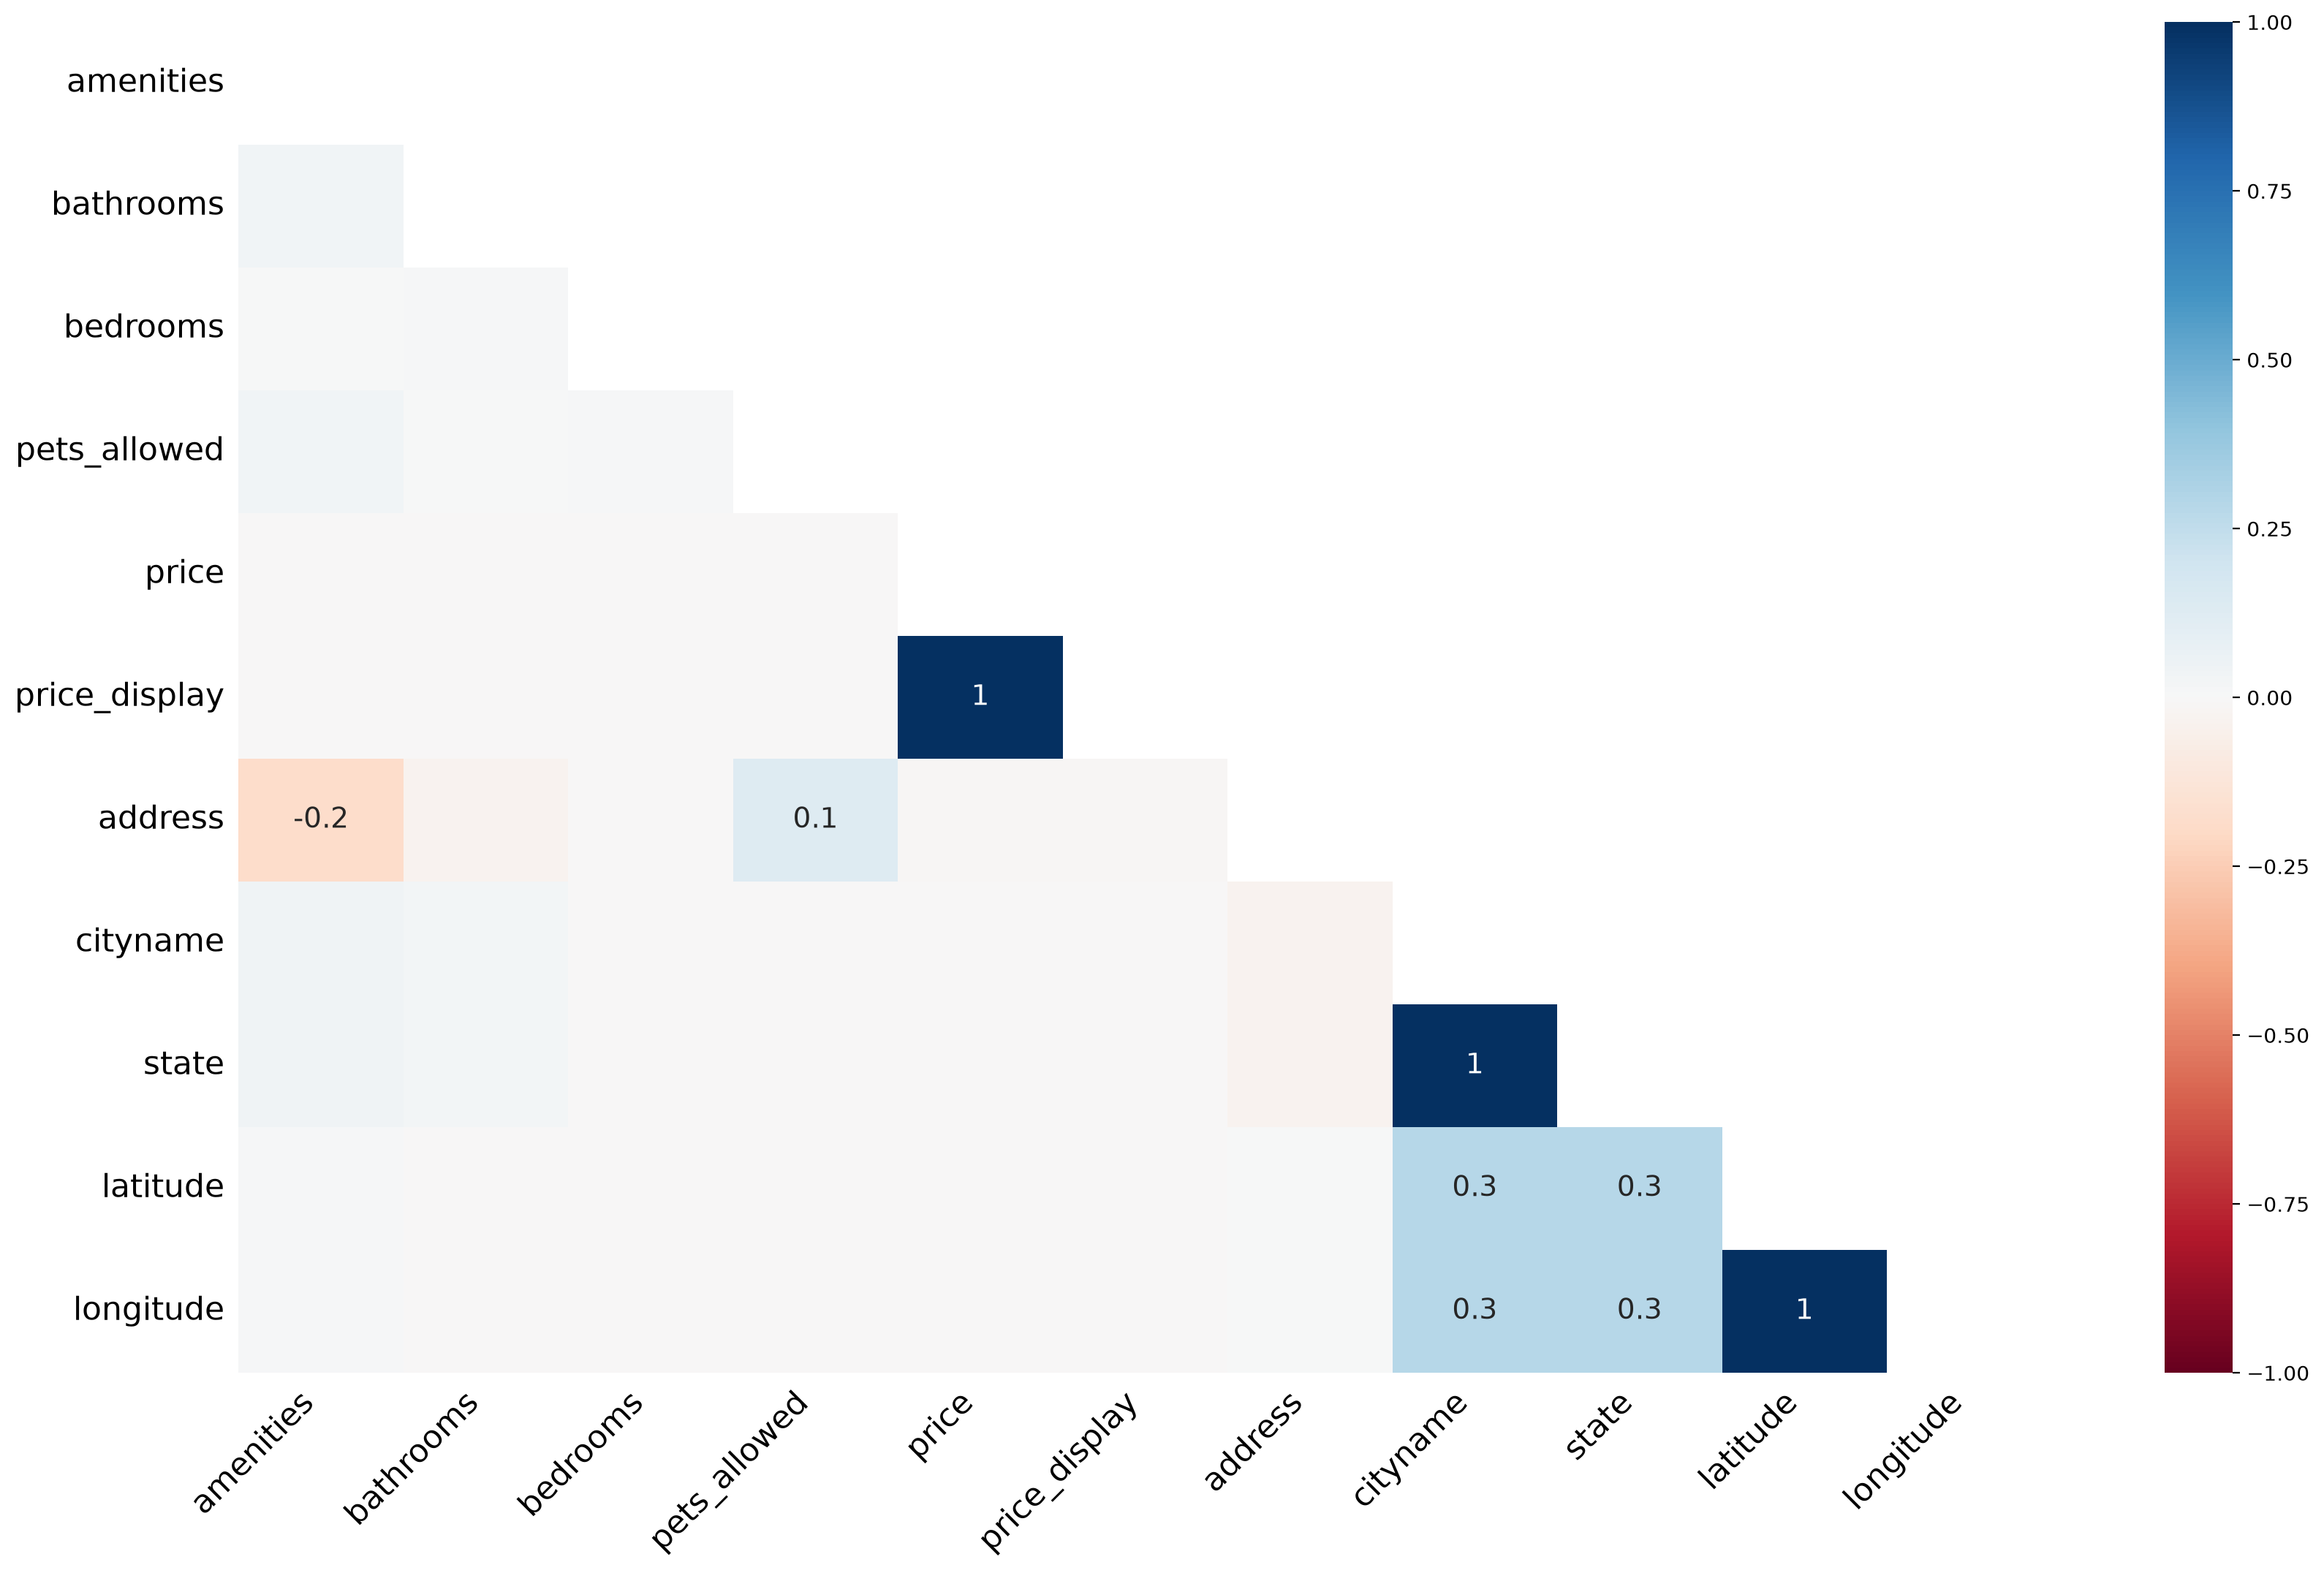

In [11]:
# wyżej jest import missingno as msno
msno.heatmap(df)


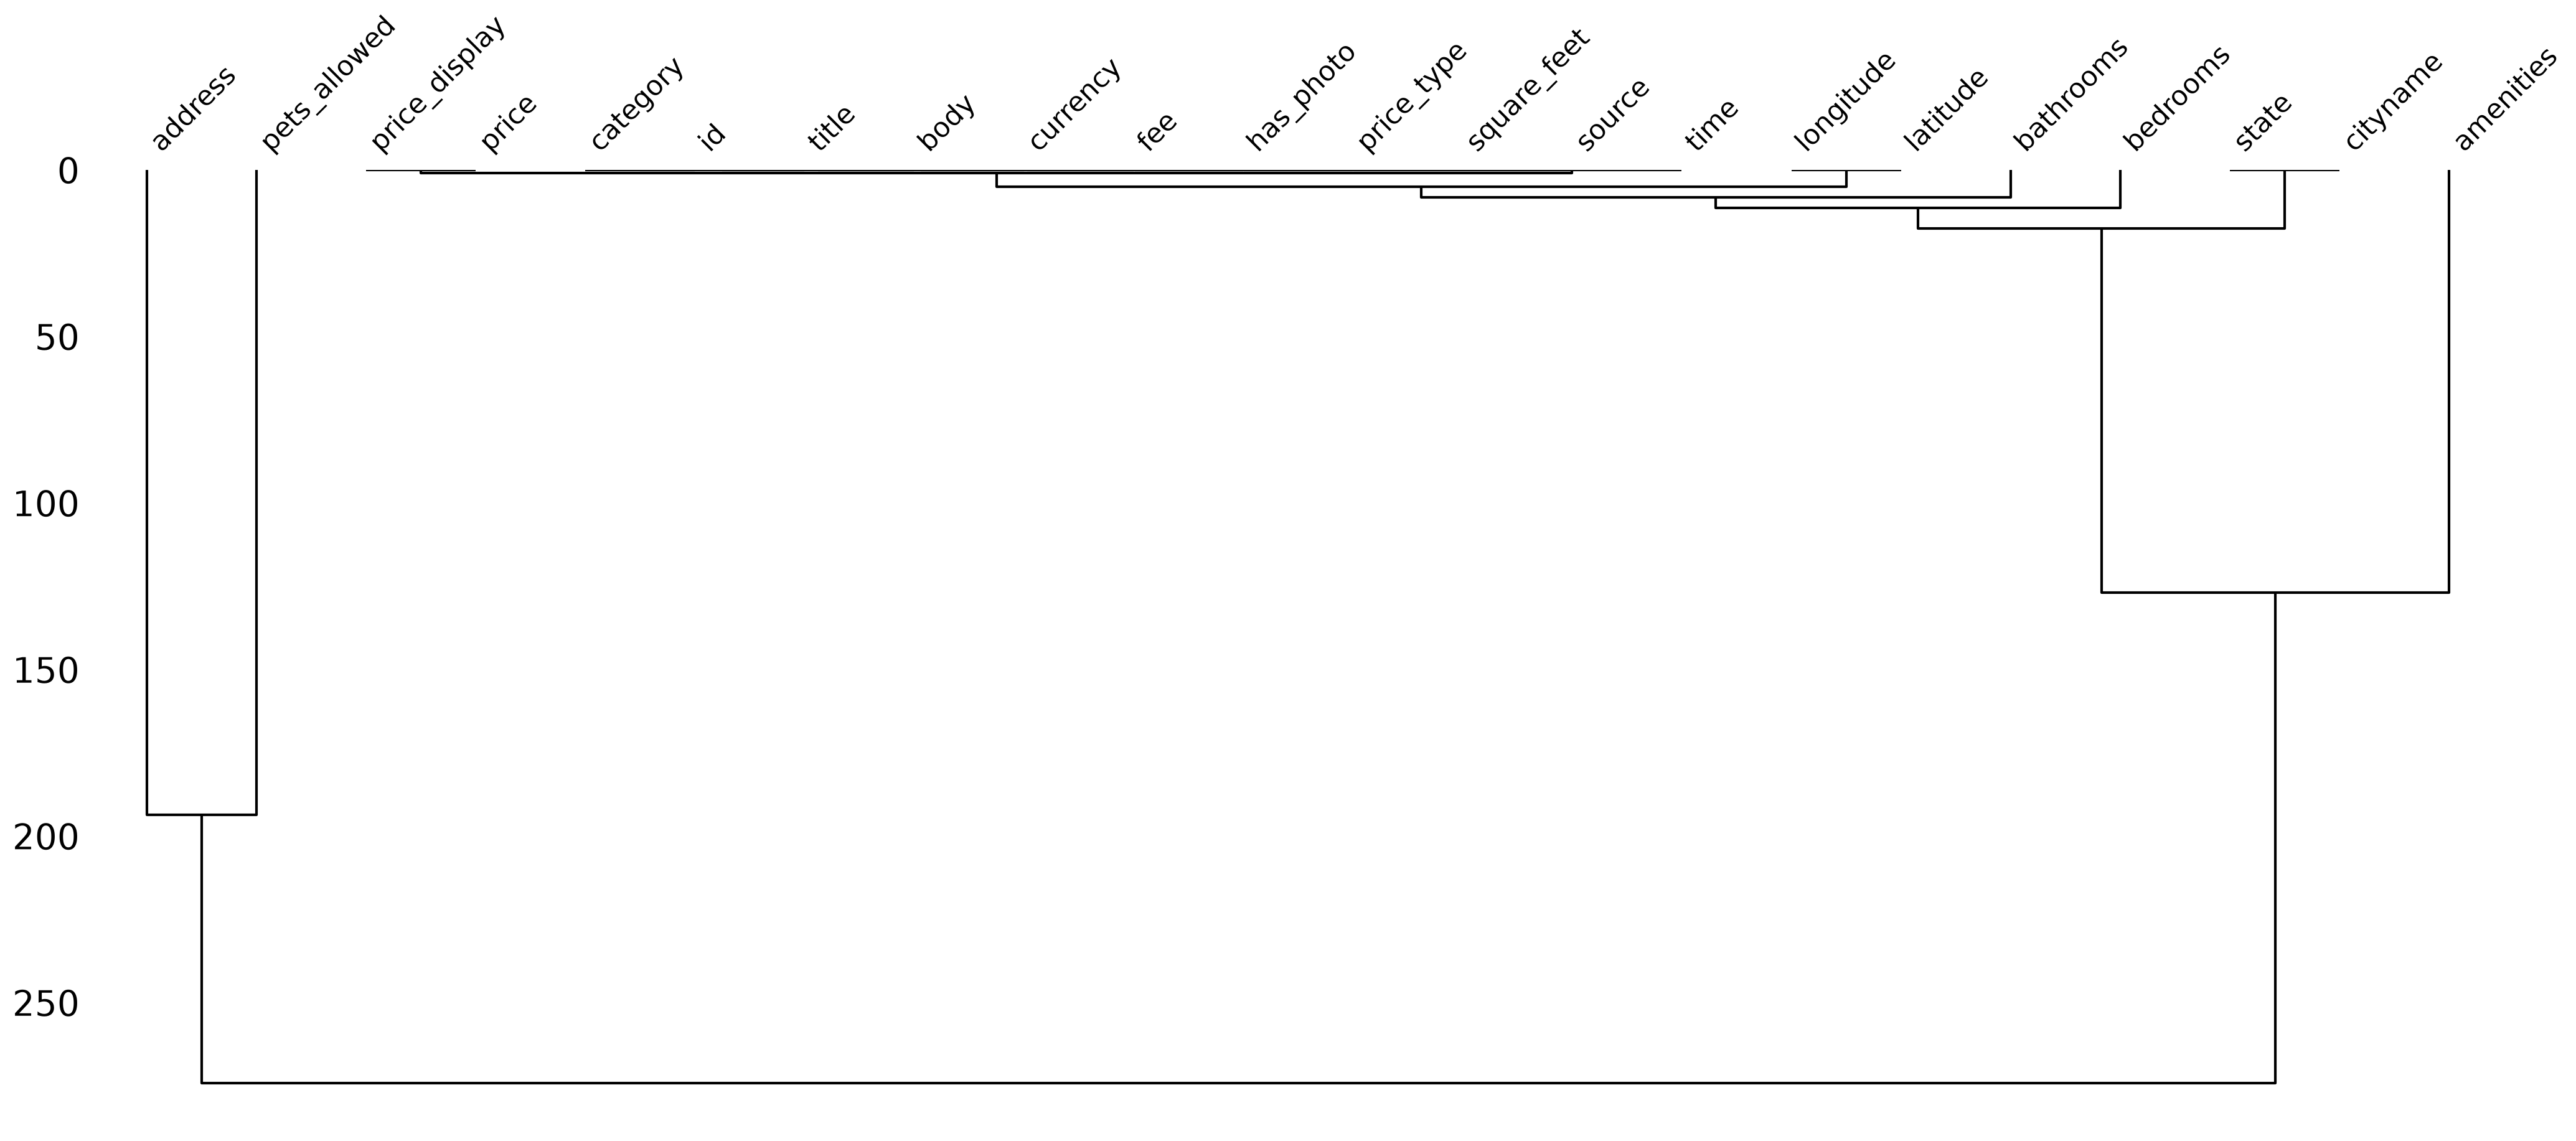

In [12]:
msno.dendrogram(df);